<a href="https://colab.research.google.com/github/Nithya-A2003/satellite-data-analysis/blob/main/Copy_of_Untitled11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving era5_u850_1979_2024.nc to era5_u850_1979_2024.nc


In [ ]:
import os

os.listdir()

['.config', 'era5_u850_1979_2024.nc', 'sample_data']

In [ ]:
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.8 MB/s eta 0:00:00


In [ ]:
import xarray as xr

ds = xr.open_dataset('era5_u850_1979_2024.nc')

print(ds)

<xarray.Dataset> Size: 188MB
Dimensions:         (valid_time: 1036, pressure_level: 1, latitude: 161,
                     longitude: 281)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2026-04-01
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 1kB 40.0 39.75 39.5 ... 0.5 0.25 0.0
  * longitude       (longitude) float64 2kB 40.0 40.25 40.5 ... 109.8 110.0
    number          int64 8B ...
    expver          (valid_time) <U4 17kB ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 187MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-04T12:01 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
print(ds.data_vars)

Data variables:
    u        (valid_time, pressure_level, latitude, longitude) float32 187MB ...


In [ ]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 1036, 'pressure_level': 1, 'latitude': 161, 'longitude': 281})


In [ ]:
print(ds.latitude)
print(ds.longitude)
print(ds.valid_time)

<xarray.DataArray 'latitude' (latitude: 161)> Size: 1kB
array([40.  , 39.75, 39.5 , 39.25, 39.  , 38.75, 38.5 , 38.25, 38.  , 37.75,
       37.5 , 37.25, 37.  , 36.75, 36.5 , 36.25, 36.  , 35.75, 35.5 , 35.25,
       35.  , 34.75, 34.5 , 34.25, 34.  , 33.75, 33.5 , 33.25, 33.  , 32.75,
       32.5 , 32.25, 32.  , 31.75, 31.5 , 31.25, 31.  , 30.75, 30.5 , 30.25,
       30.  , 29.75, 29.5 , 29.25, 29.  , 28.75, 28.5 , 28.25, 28.  , 27.75,
       27.5 , 27.25, 27.  , 26.75, 26.5 , 26.25, 26.  , 25.75, 25.5 , 25.25,
       25.  , 24.75, 24.5 , 24.25, 24.  , 23.75, 23.5 , 23.25, 23.  , 22.75,
       22.5 , 22.25, 22.  , 21.75, 21.5 , 21.25, 21.  , 20.75, 20.5 , 20.25,
       20.  , 19.75, 19.5 , 19.25, 19.  , 18.75, 18.5 , 18.25, 18.  , 17.75,
       17.5 , 17.25, 17.  , 16.75, 16.5 , 16.25, 16.  , 15.75, 15.5 , 15.25,
       15.  , 14.75, 14.5 , 14.25, 14.  , 13.75, 13.5 , 13.25, 13.  , 12.75,
       12.5 , 12.25, 12.  , 11.75, 11.5 , 11.25, 11.  , 10.75, 10.5 , 10.25,
       10.  ,  9.75,

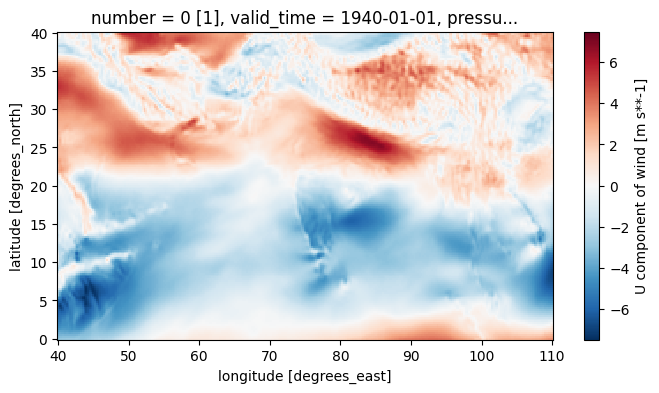

In [ ]:
ds[list(ds.data_vars)[0]].isel(valid_time=0).plot(figsize=(8,4))

In [ ]:
u = ds['u']

In [ ]:
u_region = u.sel(
    latitude=slice(20, 5),
    longitude=slice(40, 110)
)

In [ ]:
print(u_region)

<xarray.DataArray 'u' (valid_time: 1036, pressure_level: 1, latitude: 61,
                       longitude: 281)> Size: 71MB
[17758076 values with dtype=float32]
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2026-04-01
  * pressure_level  (pressure_level) float64 8B 850.0
  * latitude        (latitude) float64 488B 20.0 19.75 19.5 ... 5.5 5.25 5.0
  * longitude       (longitude) float64 2kB 40.0 40.25 40.5 ... 109.8 110.0
    number          int64 8B ...
    expver          (valid_time) <U4 17kB ...
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      45241
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:           

In [ ]:
u_mean = u_region.mean(dim=['latitude', 'longitude'])

In [ ]:
print(u_mean)

<xarray.DataArray 'u' (valid_time: 1036, pressure_level: 1)> Size: 4kB
array([[-2.3230944 ],
       [-2.6831944 ],
       [-0.19049668],
       ...,
       [-2.9779818 ],
       [-2.5016372 ],
       [-0.8871515 ]], dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2026-04-01
  * pressure_level  (pressure_level) float64 8B 850.0
    number          int64 8B ...
    expver          (valid_time) <U4 17kB ...
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      45241
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:

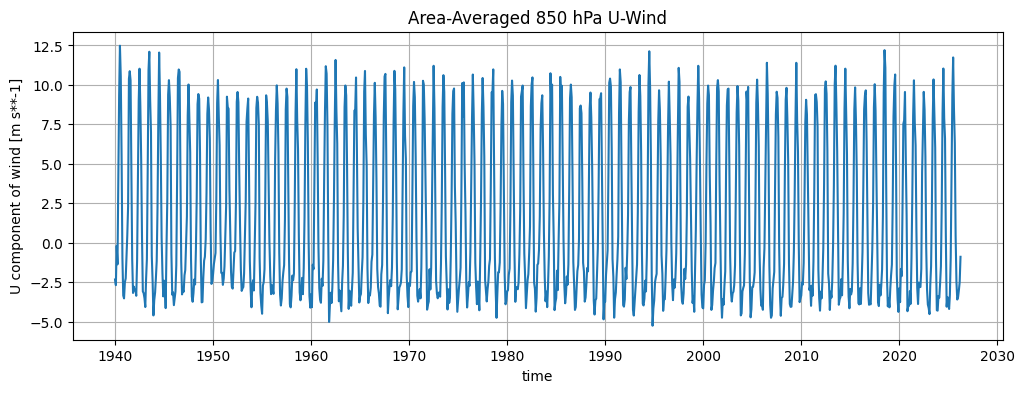

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
u_mean.plot()
plt.title('Area-Averaged 850 hPa U-Wind')
plt.grid(True)
plt.show()

In [ ]:
climatology = u_mean.groupby('valid_time.month').mean('valid_time')

In [ ]:
anomaly = u_mean.groupby('valid_time.month') - climatology

In [ ]:
print(climatology)
print(anomaly)

<xarray.DataArray 'u' (month: 12, pressure_level: 1)> Size: 48B
array([[-3.2900198 ],
       [-2.9029524 ],
       [-2.380323  ],
       [-1.0124164 ],
       [ 2.9001648 ],
       [ 8.656373  ],
       [10.134647  ],
       [ 9.071271  ],
       [ 5.2125163 ],
       [-0.46928707],
       [-3.2886534 ],
       [-3.8057425 ]], dtype=float32)
Coordinates:
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * pressure_level  (pressure_level) float64 8B 850.0
    number          (month) int64 96B 0 0 0 0 0 0 0 0 0 0 0 0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      45241
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:            

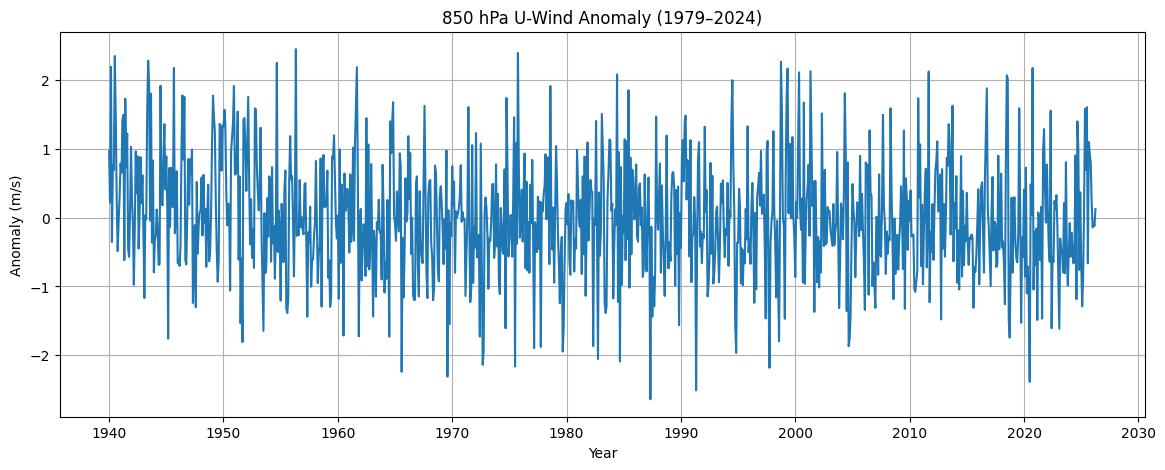

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
anomaly.plot()

plt.title('850 hPa U-Wind Anomaly (1979–2024)')
plt.xlabel('Year')
plt.ylabel('Anomaly (m/s)')
plt.grid(True)

plt.show()

In [ ]:
anomaly.to_netcdf('u850_anomaly_1979_2024.nc')


In [ ]:
jjas = anomaly.sel(
    valid_time=anomaly['valid_time'].dt.month.isin([6,7,8,9])
)

In [ ]:
dmi_jjas = jjas.groupby('valid_time.year').mean('valid_time')

In [ ]:
print(dmi_jjas)

<xarray.DataArray 'u' (year: 86, pressure_level: 1)> Size: 344B
array([[ 1.1822145 ],
       [ 0.80515087],
       [ 0.21057725],
       [ 1.5011013 ],
       [ 0.41647482],
       [ 0.80442405],
       [ 0.93894887],
       [-0.37007797],
       [-0.01374781],
       [-0.17309451],
       [ 0.07191074],
       [-0.832817  ],
       [-0.30413425],
       [-0.84425616],
       [ 0.2615348 ],
       [-0.8000113 ],
       [-0.03442943],
       [-0.35725534],
       [-0.04175889],
       [ 0.44726562],
...
       [ 0.20476937],
       [ 0.12475479],
       [-0.27761352],
       [-0.05918097],
       [-0.9558916 ],
       [ 0.4878285 ],
       [ 0.5461744 ],
       [ 0.6945381 ],
       [ 0.06332517],
       [-0.6422452 ],
       [ 0.19861293],
       [-0.38452196],
       [ 0.85664964],
       [ 0.20880604],
       [-0.74860954],
       [-0.2421062 ],
       [-0.64496946],
       [-0.14666629],
       [ 0.16857195],
       [ 0.6842538 ]], dtype=float32)
Coordinates:
  * year            (ye

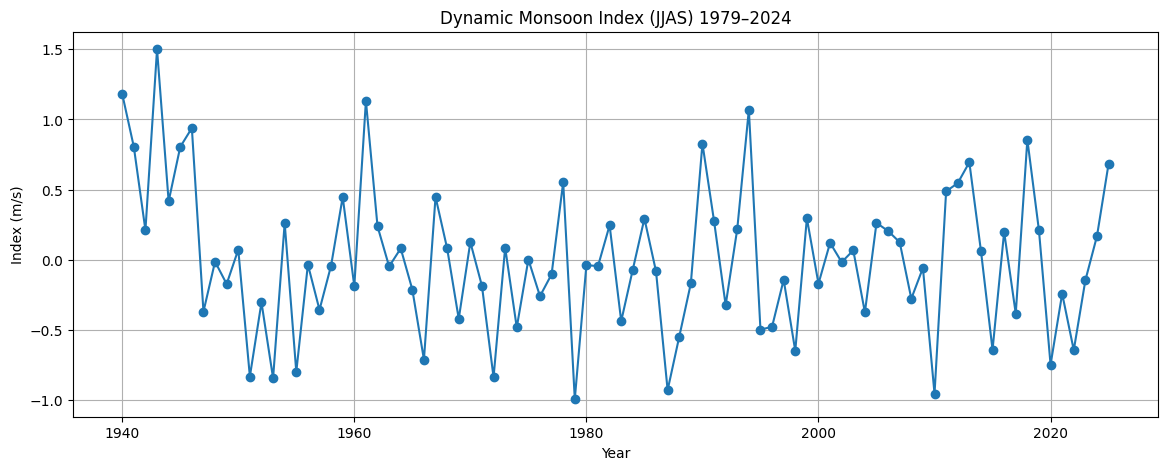

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(dmi_jjas.year, dmi_jjas, marker='o')

plt.title('Dynamic Monsoon Index (JJAS) 1979–2024')
plt.xlabel('Year')
plt.ylabel('Index (m/s)')
plt.grid(True)

plt.show()

In [ ]:
dmi_jjas.to_netcdf('DMI_JJAS_1979_2024.nc')

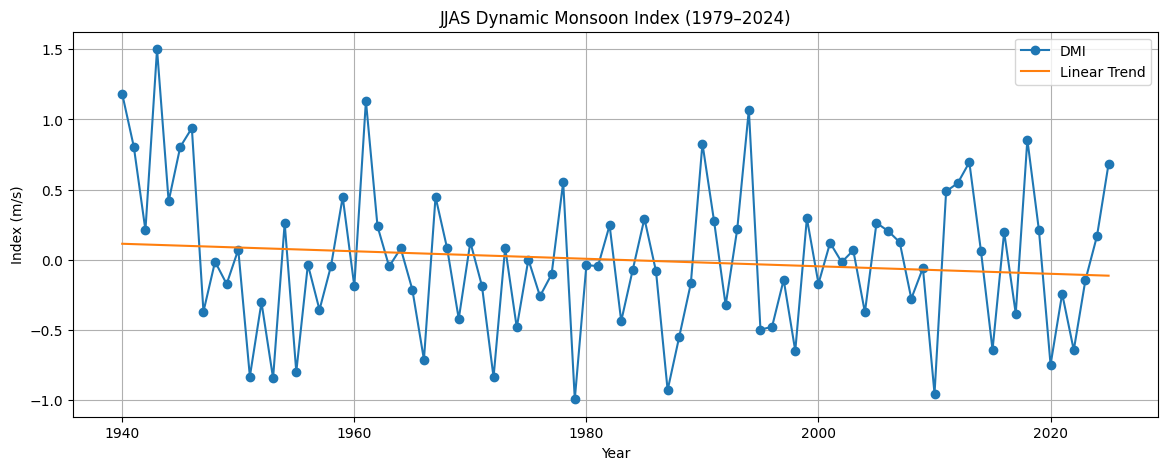

In [ ]:
import numpy as np

x = dmi_jjas.year.values
y = dmi_jjas.values

trend = np.polyfit(x, y, 1)
trendline = np.polyval(trend, x)

plt.figure(figsize=(14,5))
plt.plot(x, y, marker='o', label='DMI')
plt.plot(x, trendline, label='Linear Trend')

plt.title('JJAS Dynamic Monsoon Index (1979–2024)')
plt.xlabel('Year')
plt.ylabel('Index (m/s)')
plt.legend()
plt.grid(True)

plt.show()